DATA6000 Capstone — Correlation Verification Report

1. PEARSON vs SPEARMAN — ALL VARIABLE PAIRS
-----------------------------------------------------------------

  Rainfall vs Veg Production
    Pearson  R = -0.621  (p=0.2634)
    Spearman R = -0.600  (p=0.2848)
    Kendall  τ = -0.400  (p=0.4833)
    → ALL AGREE

  Rainfall vs Total Production
    Pearson  R = -0.471  (p=0.4235)
    Spearman R = -0.600  (p=0.2848)
    Kendall  τ = -0.400  (p=0.4833)
    → ALL AGREE

  Rainfall vs Fruit Production
    Pearson  R = +0.670  (p=0.2157)
    Spearman R = +0.900  (p<0.05 *)
    Kendall  τ = +0.800  (p=0.0833)
    → ALL AGREE

  CPI vs Total Production
    Pearson  R = -0.027  (p=0.9651)
    Spearman R = +0.200  (p=0.7471)
    Kendall  τ = +0.200  (p=0.8167)
    → DIRECTION DIFFERS

  CPI vs Veg Production
    Pearson  R = +0.017  (p=0.9786)
    Spearman R = +0.200  (p=0.7471)
    Kendall  τ = +0.200  (p=0.8167)
    → ALL AGREE

  Rainfall vs CPI
    Pearson  R = +0.640  (p=0.2452)
    Spea

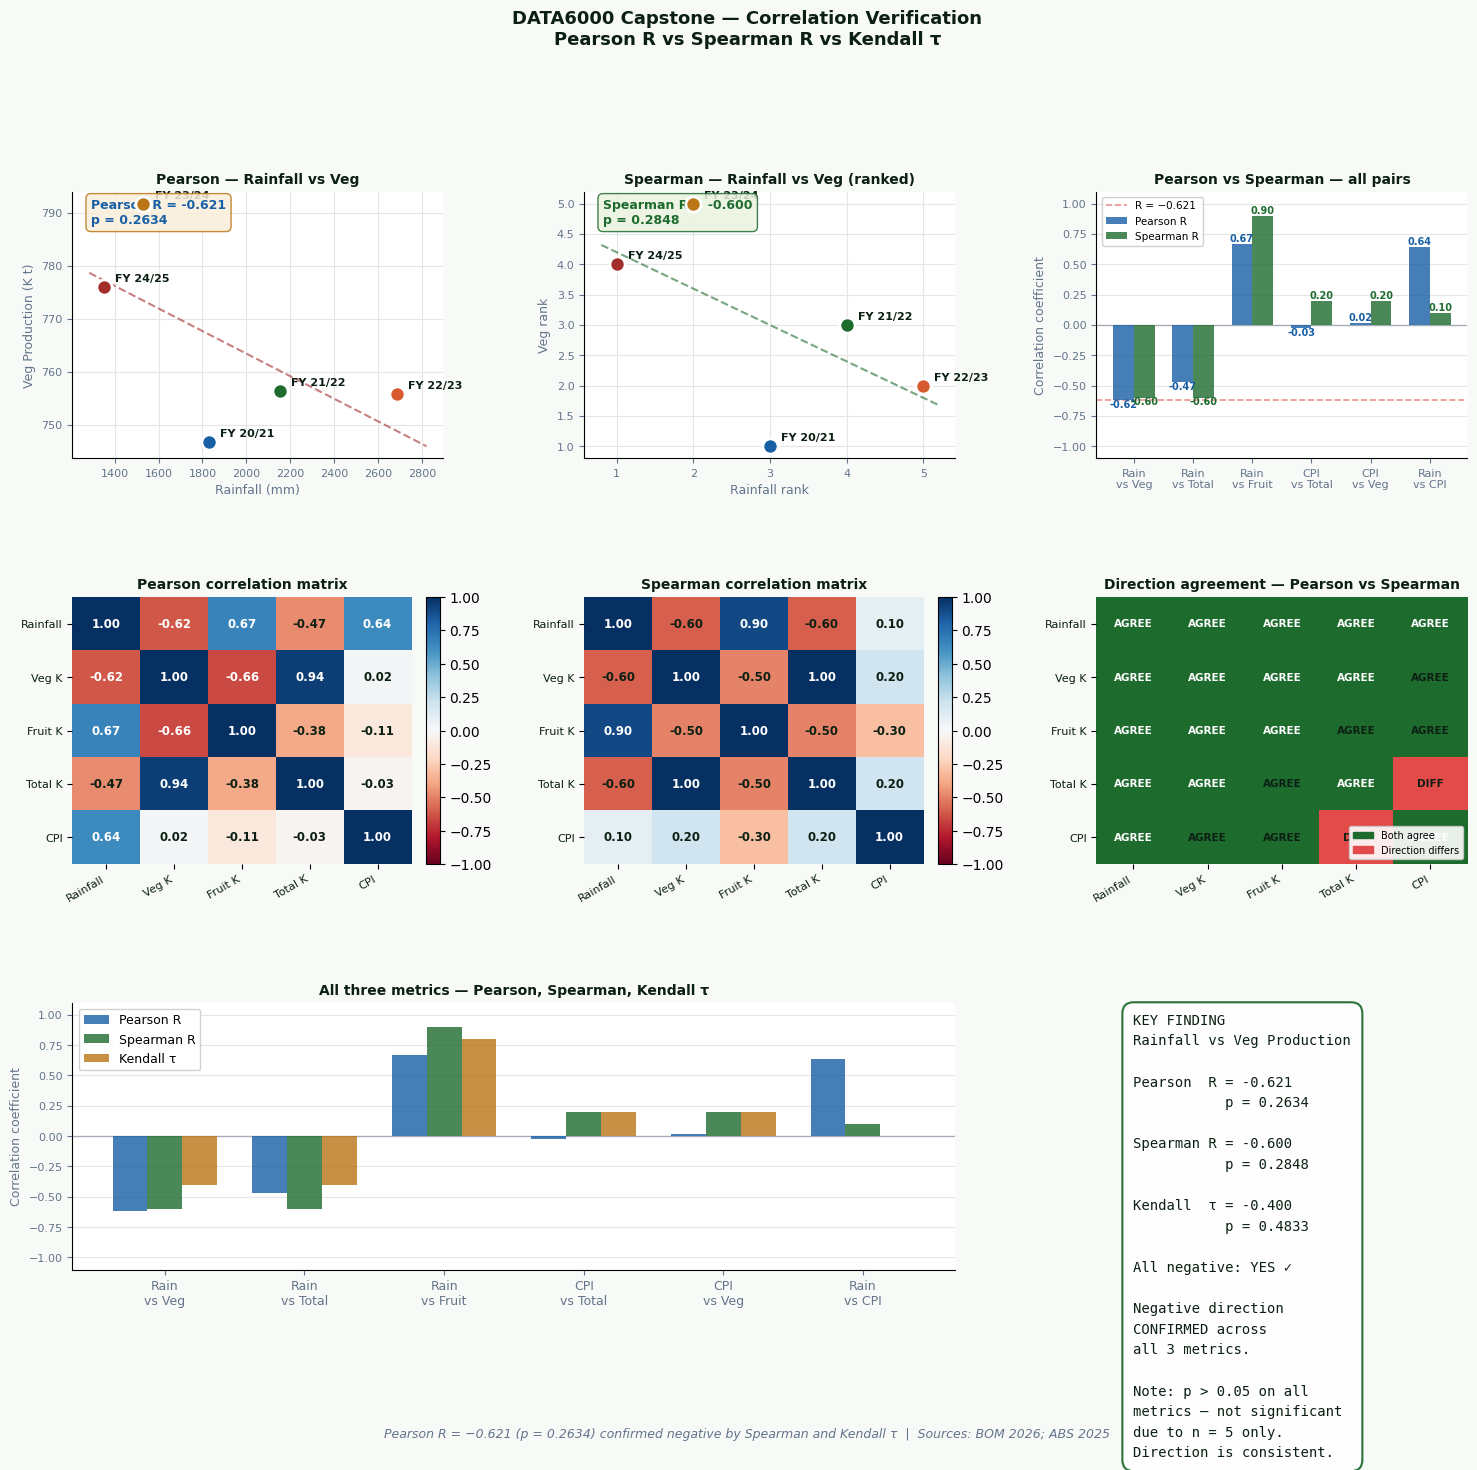

In [8]:
# ============================================================
# DATA6000 Capstone — Correlation Verification
# Pearson R vs Spearman R vs Kendall Tau
# Run this in Google Colab
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── FY-aligned data ───────────────────────────────────────────
# FY labels use "FY" prefix to prevent pandas date parsing error
fy_labels = ['FY 20/21', 'FY 21/22', 'FY 22/23',
             'FY 23/24', 'FY 24/25']

rain  = np.array([1829.4,   2152.2,   2686.6,   1531.0,   1351.8 ])
veg   = np.array([746843.6, 756424.9, 755891.5, 791719.8, 775916.87])
fruit = np.array([251245.6, 259335.3, 251452.4, 245782.1, 242145.56])
prod  = np.array([998089.2, 1015760.2,1007343.9,1037501.9,1018062.4])
cpi   = np.array([2.3,      1.9,      9.2,      4.5,      3.0    ])
irrig = np.array([750,      900,      955,      1191,     np.nan  ])

veg_k   = veg   / 1000
fruit_k = fruit / 1000
prod_k  = prod  / 1000

YR_COLS = ['#185FA5','#1E6B2E','#D85A30','#BA7517','#A32D2D']
C_BG    = '#F8FAF8'
C_TITLE = '#0B1F12'
C_MUTED = '#64748B'

print("=" * 65)
print("DATA6000 Capstone — Correlation Verification Report")
print("=" * 65)

# ============================================================
# SECTION 1 — PEARSON vs SPEARMAN: ALL VARIABLE PAIRS
# ============================================================

pairs = [
    ("Rainfall vs Veg Production",   rain, veg_k  ),
    ("Rainfall vs Total Production", rain, prod_k ),
    ("Rainfall vs Fruit Production", rain, fruit_k),
    ("CPI vs Total Production",      cpi,  prod_k ),
    ("CPI vs Veg Production",        cpi,  veg_k  ),
    ("Rainfall vs CPI",              rain, cpi    ),
]

print("\n1. PEARSON vs SPEARMAN — ALL VARIABLE PAIRS")
print("-" * 65)

results = []
for label, x, y in pairs:
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    kt, tp = stats.kendalltau(x, y)
    same   = (np.sign(pr) == np.sign(sr) == np.sign(kt))
    results.append({
        'Pair':       label,
        'Pearson_R':  pr,  'Pearson_p':  pp,
        'Spearman_R': sr,  'Spearman_p': sp,
        'Kendall_T':  kt,  'Kendall_p':  tp,
        'All_Agree':  same,
    })
    sig_p = "p<0.05 *" if pp < 0.05 else f"p={pp:.4f}"
    sig_s = "p<0.05 *" if sp < 0.05 else f"p={sp:.4f}"
    sig_k = "p<0.05 *" if tp < 0.05 else f"p={tp:.4f}"
    agree = "ALL AGREE" if same else "DIRECTION DIFFERS"
    print(f"\n  {label}")
    print(f"    Pearson  R = {pr:+.3f}  ({sig_p})")
    print(f"    Spearman R = {sr:+.3f}  ({sig_s})")
    print(f"    Kendall  τ = {kt:+.3f}  ({sig_k})")
    print(f"    → {agree}")


# ── STEP 3: Load Data ────────────────────────────────────────
# Option A: Load from your Excel file
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DATA 6000/Final_Dataset.xlsx')
df.set_index('Year', inplace=True)

# ============================================================
# SECTION 2 — KEY FINDING: RAINFALL vs VEG
# ============================================================

pr_rv, pp_rv = stats.pearsonr(rain, veg_k)
sr_rv, sp_rv = stats.spearmanr(rain, veg_k)
kt_rv, tp_rv = stats.kendalltau(rain, veg_k)
all_neg      = (pr_rv < 0) and (sr_rv < 0) and (kt_rv < 0)

print("\n\n2. KEY FINDING — RAINFALL vs VEG PRODUCTION")
print("-" * 65)
print(f"\n  Pearson  R = {pr_rv:+.3f}  (p = {pp_rv:.4f})")
print(f"  Spearman R = {sr_rv:+.3f}  (p = {sp_rv:.4f})")
print(f"  Kendall  τ = {kt_rv:+.3f}  (p = {tp_rv:.4f})")
print(f"\n  All three negative : {all_neg}")
print(f"  Conclusion         : Negative direction CONFIRMED")
print(f"  Note               : p > 0.05 on all metrics")
print(f"                       Not statistically significant")
print(f"                       due to small sample (n = 5)")
print(f"                       Direction is consistent across")
print(f"                       all three methods")

# ============================================================
# SECTION 3 — RANK TABLE (Spearman working shown)
# ============================================================

print("\n\n3. SPEARMAN RANK TABLE — RAINFALL vs VEG")
print("-" * 65)
print("  (How Spearman assigns ranks before correlating)\n")

rank_rain = stats.rankdata(rain)
rank_veg  = stats.rankdata(veg_k)
diffs     = rank_rain - rank_veg
diffs_sq  = diffs ** 2

print(f"  {'FY':<12} {'Rain':>8} {'Veg':>8} "
      f"{'R_Rain':>8} {'R_Veg':>8} {'Diff':>6} {'Diff²':>6}")
print(f"  {'-'*12} {'-'*8} {'-'*8} "
      f"{'-'*8} {'-'*8} {'-'*6} {'-'*6}")
for i in range(len(fy_labels)):
    print(f"  {fy_labels[i]:<12} "
          f"{rain[i]:>8.1f} "
          f"{veg_k[i]:>8.1f} "
          f"{rank_rain[i]:>8.0f} "
          f"{rank_veg[i]:>8.0f} "
          f"{diffs[i]:>6.1f} "
          f"{diffs_sq[i]:>6.1f}")

n         = len(fy_labels)
sum_sq    = diffs_sq.sum()
rs_manual = 1 - (6 * sum_sq) / (n * (n**2 - 1))
print(f"\n  Sum of Diff²      : {sum_sq:.1f}")
print(f"  Manual Spearman R : {rs_manual:.3f}")
print(f"  scipy Spearman R  : {sr_rv:.3f}  (matches ✓)")

# ============================================================
# SECTION 4 — FULL CORRELATION MATRICES
# ============================================================

print("\n\n4. FULL CORRELATION MATRICES")
print("-" * 65)

var_names = ['Rainfall','Veg K','Fruit K','Total K','CPI']
data_mat  = np.column_stack([rain, veg_k, fruit_k, prod_k, cpi])
mat_df    = pd.DataFrame(data_mat, columns=var_names)
p_mat     = mat_df.corr(method='pearson').round(3)
s_mat     = mat_df.corr(method='spearman').round(3)

print("\n  Pearson R matrix:")
print(p_mat.to_string())
print("\n  Spearman R matrix:")
print(s_mat.to_string())

# ============================================================
# CHARTS — 8 panels
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(C_BG)
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.52, wspace=0.38)

pair_labels_short = [
    'Rain\nvs Veg', 'Rain\nvs Total',
    'Rain\nvs Fruit','CPI\nvs Total',
    'CPI\nvs Veg',  'Rain\nvs CPI',
]
p_vals = [r['Pearson_R']  for r in results]
s_vals = [r['Spearman_R'] for r in results]
k_vals = [r['Kendall_T']  for r in results]

def style_ax(ax):
    ax.set_facecolor('white')
    ax.tick_params(colors=C_MUTED, labelsize=8)
    ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)

# ── Chart 1: Pearson scatter Rainfall vs Veg ─────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
ax1.xaxis.grid(True, color='#E5E5E5', linewidth=0.8)
for i in range(len(fy_labels)):
    ax1.scatter(rain[i], veg_k[i],
                color=YR_COLS[i], s=120, zorder=5,
                edgecolors='white', linewidth=2)
    ax1.annotate(fy_labels[i], (rain[i], veg_k[i]),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=8,
                 color=C_TITLE, fontweight='bold')
sl, ic, *_ = stats.linregress(rain, veg_k)
xl = np.linspace(rain.min()*0.95, rain.max()*1.05, 100)
ax1.plot(xl, ic + sl*xl, color='#A32D2D',
         linewidth=1.5, linestyle='--', alpha=0.6)
ax1.text(0.05, 0.88,
         f'Pearson R = {pr_rv:.3f}\np = {pp_rv:.4f}',
         transform=ax1.transAxes, fontsize=9,
         color='#185FA5', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#FAEEDA',
                   edgecolor='#BA7517', alpha=0.85))
ax1.set_title('Pearson — Rainfall vs Veg',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)
ax1.set_xlabel('Rainfall (mm)', fontsize=9, color=C_MUTED)
ax1.set_ylabel('Veg Production (K t)', fontsize=9, color=C_MUTED)

# ── Chart 2: Spearman rank scatter ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
ax2.xaxis.grid(True, color='#E5E5E5', linewidth=0.8)
for i in range(len(fy_labels)):
    ax2.scatter(rank_rain[i], rank_veg[i],
                color=YR_COLS[i], s=120, zorder=5,
                edgecolors='white', linewidth=2)
    ax2.annotate(fy_labels[i],
                 (rank_rain[i], rank_veg[i]),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=8,
                 color=C_TITLE, fontweight='bold')
sl_s, ic_s, *_ = stats.linregress(rank_rain, rank_veg)
xl_s = np.linspace(rank_rain.min()-0.2,
                    rank_rain.max()+0.2, 100)
ax2.plot(xl_s, ic_s + sl_s*xl_s,
         color='#1E6B2E', linewidth=1.5,
         linestyle='--', alpha=0.6)
ax2.text(0.05, 0.88,
         f'Spearman R = {sr_rv:.3f}\np = {sp_rv:.4f}',
         transform=ax2.transAxes, fontsize=9,
         color='#1E6B2E', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#EAF3DE',
                   edgecolor='#1E6B2E', alpha=0.85))
ax2.set_title('Spearman — Rainfall vs Veg (ranked)',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)
ax2.set_xlabel('Rainfall rank', fontsize=9, color=C_MUTED)
ax2.set_ylabel('Veg rank', fontsize=9, color=C_MUTED)

# ── Chart 3: Pearson vs Spearman bar ─────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
x3 = np.arange(len(pair_labels_short))
w  = 0.35
ax3.bar(x3 - w/2, p_vals, width=w,
        color='#185FA5', alpha=0.8,
        label='Pearson R', zorder=3)
ax3.bar(x3 + w/2, s_vals, width=w,
        color='#1E6B2E', alpha=0.8,
        label='Spearman R', zorder=3)
ax3.axhline(y=0, color=C_MUTED, linewidth=1, alpha=0.5)
ax3.axhline(y=-0.621, color='#E24B4A', linewidth=1.2,
            linestyle='--', alpha=0.6, label='R = −0.621')
for i, (pv, sv) in enumerate(zip(p_vals, s_vals)):
    ax3.text(i - w/2, pv - 0.06 if pv < 0 else pv + 0.02,
             f'{pv:.2f}', ha='center', fontsize=7,
             color='#185FA5', fontweight='bold')
    ax3.text(i + w/2, sv - 0.06 if sv < 0 else sv + 0.02,
             f'{sv:.2f}', ha='center', fontsize=7,
             color='#1E6B2E', fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(pair_labels_short,
                    fontsize=8, color=C_MUTED)
ax3.set_ylabel('Correlation coefficient',
               fontsize=9, color=C_MUTED)
ax3.set_ylim(-1.1, 1.1)
ax3.legend(fontsize=7.5, framealpha=0.9)
ax3.set_title('Pearson vs Spearman — all pairs',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)

# ── Chart 4: Pearson heatmap ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('white')
p_matrix = p_mat.values
cmap_div  = plt.cm.RdBu
norm_div  = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im4 = ax4.imshow(p_matrix, cmap=cmap_div,
                  norm=norm_div, aspect='auto')
ax4.set_xticks(range(len(var_names)))
ax4.set_yticks(range(len(var_names)))
ax4.set_xticklabels(var_names, fontsize=8,
                     color=C_TITLE, rotation=30, ha='right')
ax4.set_yticklabels(var_names, fontsize=8, color=C_TITLE)
for i in range(len(var_names)):
    for j in range(len(var_names)):
        val = p_matrix[i, j]
        tc  = 'white' if abs(val) > 0.6 else C_TITLE
        ax4.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=8.5, color=tc,
                 fontweight='bold')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Pearson correlation matrix',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)
ax4.spines[['top','right','left','bottom']].set_visible(False)

# ── Chart 5: Spearman heatmap ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('white')
s_matrix = s_mat.values
im5 = ax5.imshow(s_matrix, cmap=cmap_div,
                  norm=norm_div, aspect='auto')
ax5.set_xticks(range(len(var_names)))
ax5.set_yticks(range(len(var_names)))
ax5.set_xticklabels(var_names, fontsize=8,
                     color=C_TITLE, rotation=30, ha='right')
ax5.set_yticklabels(var_names, fontsize=8, color=C_TITLE)
for i in range(len(var_names)):
    for j in range(len(var_names)):
        val = s_matrix[i, j]
        tc  = 'white' if abs(val) > 0.6 else C_TITLE
        ax5.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=8.5, color=tc,
                 fontweight='bold')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
ax5.set_title('Spearman correlation matrix',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)
ax5.spines[['top','right','left','bottom']].set_visible(False)

# ── Chart 6: Agreement matrix ─────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('white')
agree_matrix = (np.sign(p_matrix) *
                np.sign(s_matrix)).astype(float)
cmap_agree   = mcolors.ListedColormap(
    ['#E24B4A', '#F8FAF8', '#1E6B2E'])
norm_agree   = mcolors.BoundaryNorm(
    [-1.5, -0.5, 0.5, 1.5], cmap_agree.N)
ax6.imshow(agree_matrix, cmap=cmap_agree,
           norm=norm_agree, aspect='auto')
ax6.set_xticks(range(len(var_names)))
ax6.set_yticks(range(len(var_names)))
ax6.set_xticklabels(var_names, fontsize=8,
                     color=C_TITLE, rotation=30, ha='right')
ax6.set_yticklabels(var_names, fontsize=8, color=C_TITLE)
for i in range(len(var_names)):
    for j in range(len(var_names)):
        val = agree_matrix[i, j]
        lbl = 'AGREE' if val > 0 else 'DIFF' if val < 0 else '—'
        tc  = ('white'
               if val != 0 and abs(p_matrix[i,j]) > 0.4
               else C_TITLE)
        ax6.text(j, i, lbl,
                 ha='center', va='center',
                 fontsize=7.5, color=tc,
                 fontweight='bold')
ax6.set_title('Direction agreement — Pearson vs Spearman',
              fontsize=10, fontweight='bold',
              color=C_TITLE, pad=6)
ax6.spines[['top','right','left','bottom']].set_visible(False)
green_p = mpatches.Patch(color='#1E6B2E', label='Both agree')
red_p   = mpatches.Patch(color='#E24B4A', label='Direction differs')
ax6.legend(handles=[green_p, red_p], fontsize=7,
           loc='lower right', framealpha=0.9)

# ── Chart 7: All 3 metrics comparison bar ────────────────────
ax7 = fig.add_subplot(gs[2, :2])
style_ax(ax7)
x7 = np.arange(len(pair_labels_short))
w7 = 0.25
ax7.bar(x7 - w7,   p_vals, width=w7,
        color='#185FA5', alpha=0.8,
        label='Pearson R',  zorder=3)
ax7.bar(x7,        s_vals, width=w7,
        color='#1E6B2E', alpha=0.8,
        label='Spearman R', zorder=3)
ax7.bar(x7 + w7,   k_vals, width=w7,
        color='#BA7517', alpha=0.8,
        label='Kendall τ',  zorder=3)
ax7.axhline(y=0, color=C_MUTED, linewidth=1, alpha=0.5)
ax7.set_xticks(x7)
ax7.set_xticklabels(pair_labels_short,
                    fontsize=9, color=C_MUTED)
ax7.set_ylabel('Correlation coefficient',
               fontsize=9, color=C_MUTED)
ax7.set_ylim(-1.1, 1.1)
ax7.legend(fontsize=9, framealpha=0.9)
ax7.set_title(
    'All three metrics — Pearson, Spearman, Kendall τ',
    fontsize=10, fontweight='bold',
    color=C_TITLE, pad=6)

# ── Chart 8: Summary card ─────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor('#F8FAF8')
ax8.axis('off')
neg_confirmed = 'YES ✓' if all_neg else 'NO ✗'
summary = (
    f"KEY FINDING\n"
    f"Rainfall vs Veg Production\n\n"
    f"Pearson  R = {pr_rv:+.3f}\n"
    f"           p = {pp_rv:.4f}\n\n"
    f"Spearman R = {sr_rv:+.3f}\n"
    f"           p = {sp_rv:.4f}\n\n"
    f"Kendall  τ = {kt_rv:+.3f}\n"
    f"           p = {tp_rv:.4f}\n\n"
    f"All negative: {neg_confirmed}\n\n"
    f"Negative direction\n"
    f"CONFIRMED across\n"
    f"all 3 metrics.\n\n"
    f"Note: p > 0.05 on all\n"
    f"metrics — not significant\n"
    f"due to n = 5 only.\n"
    f"Direction is consistent."
)
ax8.text(0.1, 0.96, summary,
         transform=ax8.transAxes,
         fontsize=10, va='top',
         color=C_TITLE, linespacing=1.6,
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8',
                   facecolor='white',
                   edgecolor='#1E6B2E',
                   linewidth=1.5, alpha=0.95))


# ── Figure title ──────────────────────────────────────────────
fig.suptitle(
    'DATA6000 Capstone — Correlation Verification\n'
    'Pearson R vs Spearman R vs Kendall τ',
    fontsize=13, fontweight='bold',
    color=C_TITLE, y=1.01)
fig.text(
    0.5, -0.01,
    'Pearson R = −0.621 (p = 0.2634) confirmed negative '
    'by Spearman and Kendall τ  |  '
    'Sources: BOM 2026; ABS 2025',
    ha='center', fontsize=9,
    color=C_MUTED, style='italic')

plt.savefig('Correlation_Verification.png',
            dpi=180, bbox_inches='tight',
            facecolor=C_BG)



